In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import MinMaxScaler
from sklearn.svm import SVC, SVR
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score
from sklearn.metrics import r2_score, mean_squared_error, mean_absolute_error
from sklearn.linear_model import LogisticRegression
from sklearn.linear_model import LinearRegression
from sklearn.ensemble import VotingClassifier
from sklearn.neighbors import KNeighborsClassifier, KNeighborsRegressor
from sklearn.cluster import KMeans
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense
from scipy import stats

In [ ]:
from tensorflow.keras.callbacks import EarlyStopping
import numpy as np
from sklearn.model_selection import GridSearchCV


In [ ]:
df=pd.read_csv('cardio_train.csv',sep=";")
df

,id,age,gender,height,weight,ap_hi,ap_lo,cholesterol,gluc,smoke,alco,active,cardio
0,0,18393,2,168,62.0,110,80,1,1,0,0,1,0
1,1,20228,1,156,85.0,140,90,3,1,0,0,1,1
2,2,18857,1,165,64.0,130,70,3,1,0,0,0,1
3,3,17623,2,169,82.0,150,100,1,1,0,0,1,1
4,4,17474,1,156,56.0,100,60,1,1,0,0,0,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...
69995,99993,19240,2,168,76.0,120,80,1,1,1,0,1,0
69996,99995,22601,1,158,126.0,140,90,2,2,0,0,1,1
69997,99996,19066,2,183,105.0,180,90,3,1,0,1,0,1
69998,99998,22431,1,163,72.0,135,80,1,2,0,0,0,1


# Preprocessing

In [ ]:
df.duplicated().sum()

0

In [ ]:
df.isnull().sum()

,0
id,0
age,0
gender,0
height,0
weight,0
ap_hi,0
ap_lo,0
cholesterol,0
gluc,0
smoke,0


In [ ]:
df.dtypes

,0
id,int64
age,int64
gender,int64
height,int64
weight,float64
ap_hi,int64
ap_lo,int64
cholesterol,int64
gluc,int64
smoke,int64


In [ ]:
# some preprocessing and feature engineer
df['age']=(df['age']/365.25).round()
df

,id,age,gender,height,weight,ap_hi,ap_lo,cholesterol,gluc,smoke,alco,active,cardio
0,0,50.0,2,168,62.0,110,80,1,1,0,0,1,0
1,1,55.0,1,156,85.0,140,90,3,1,0,0,1,1
2,2,52.0,1,165,64.0,130,70,3,1,0,0,0,1
3,3,48.0,2,169,82.0,150,100,1,1,0,0,1,1
4,4,48.0,1,156,56.0,100,60,1,1,0,0,0,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...
69995,99993,53.0,2,168,76.0,120,80,1,1,1,0,1,0
69996,99995,62.0,1,158,126.0,140,90,2,2,0,0,1,1
69997,99996,52.0,2,183,105.0,180,90,3,1,0,1,0,1
69998,99998,61.0,1,163,72.0,135,80,1,2,0,0,0,1


In [ ]:
# Get all categorical columns
categorical_columns = df.select_dtypes(include=['object', 'category']).columns
print("Categorical Columns:", categorical_columns)

Categorical Columns: Index([], dtype='object')


# Feature Engineering

In [ ]:
df['bmi'] = df['weight'] / ((df['height']/100)**2)
df = df[(df['bmi'] >= 15) & (df['bmi'] <= 50)]

In [ ]:
df['pulse_pressure'] = df['ap_hi'] - df['ap_lo']
df['hypertension'] = ((df['ap_hi'] >= 140) | (df['ap_lo'] >= 90)).astype(int)
df['obesity'] = (df['bmi'] >= 30).astype(int)

df = df.drop(columns=['height', 'weight', 'ap_hi', 'ap_lo','id'])


<ipython-input-10-302dddc6cff0>:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df['pulse_pressure'] = df['ap_hi'] - df['ap_lo']
<ipython-input-10-302dddc6cff0>:2: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df['hypertension'] = ((df['ap_hi'] >= 140) | (df['ap_lo'] >= 90)).astype(int)
<ipython-input-10-302dddc6cff0>:3: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: h

In [ ]:
x = df.drop('cardio', axis = 1)
y = df['cardio']

In [ ]:
from sklearn.preprocessing import StandardScaler

In [ ]:
scaler = StandardScaler()
X_scaled = scaler.fit_transform(x)

In [ ]:
from imblearn.combine import SMOTEENN

In [ ]:
smotenn = SMOTEENN(random_state=42)
X_scaled, y= smotenn.fit_resample(X_scaled, y)

In [ ]:
x_train, x_test, y_train, y_test = train_test_split(X_scaled, y, test_size=0.2, random_state=42)

In [ ]:
print(x.shape)
print(x_train.shape)

(69729, 11)
(19504, 11)


In [ ]:
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report

In [ ]:
from sklearn.naive_bayes import GaussianNB

In [ ]:
model = GaussianNB()
model.fit(x_train, y_train)


y_pred = model.predict(x_test)
print("Accuracy:", accuracy_score(y_test, y_pred))
print("\nConfusion Matrix:\n", confusion_matrix(y_test, y_pred))
print("\nClassification Report:\n", classification_report(y_test, y_pred))

Accuracy: 0.9302707136997539

Confusion Matrix:
 [[2285  165]
 [ 175 2251]]

Classification Report:
               precision    recall  f1-score   support

           0       0.93      0.93      0.93      2450
           1       0.93      0.93      0.93      2426

    accuracy                           0.93      4876
   macro avg       0.93      0.93      0.93      4876
weighted avg       0.93      0.93      0.93      4876



In [ ]:
from sklearn.model_selection import learning_curve


/usr/local/lib/python3.11/dist-packages/sklearn/naive_bayes.py:513: RuntimeWarning: divide by zero encountered in log
  n_ij = -0.5 * np.sum(np.log(2.0 * np.pi * self.var_[i, :]))
/usr/local/lib/python3.11/dist-packages/sklearn/naive_bayes.py:514: RuntimeWarning: divide by zero encountered in divide
  n_ij -= 0.5 * np.sum(((X - self.theta_[i, :]) ** 2) / (self.var_[i, :]), 1)
/usr/local/lib/python3.11/dist-packages/sklearn/naive_bayes.py:514: RuntimeWarning: invalid value encountered in divide
  n_ij -= 0.5 * np.sum(((X - self.theta_[i, :]) ** 2) / (self.var_[i, :]), 1)
/usr/local/lib/python3.11/dist-packages/sklearn/naive_bayes.py:513: RuntimeWarning: divide by zero encountered in log
  n_ij = -0.5 * np.sum(np.log(2.0 * np.pi * self.var_[i, :]))
/usr/local/lib/python3.11/dist-packages/sklearn/naive_bayes.py:514: RuntimeWarning: invalid value encountered in divide
  n_ij -= 0.5 * np.sum(((X - self.theta_[i, :]) ** 2) / (self.var_[i, :]), 1)
/usr/local/lib/python3.11/dist-packages/sklea

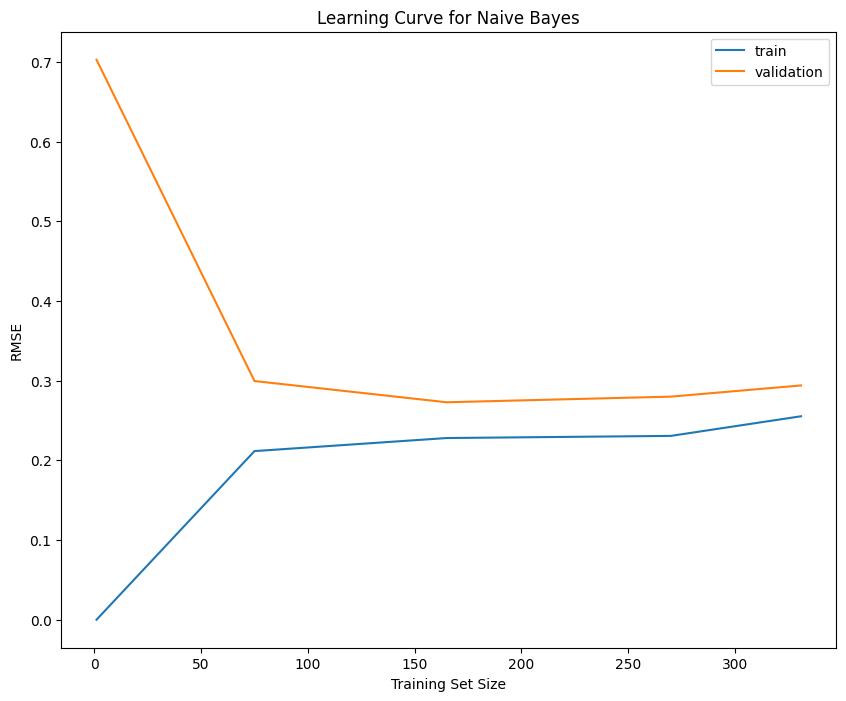

In [ ]:
train_sizes, train_scores, test_scores = learning_curve(
    estimator=model,
    X=x_train,
    y=y_train,
    cv=5,
    scoring="neg_root_mean_squared_error",
    train_sizes = [1, 75, 165, 270, 331]
)

train_mean = -train_scores.mean(axis=1)
test_mean = -test_scores.mean(axis=1)

plt.subplots(figsize=(10,8))
plt.plot(train_sizes, train_mean, label="train")
plt.plot(train_sizes, test_mean, label="validation")

plt.title("Learning Curve for Naive Bayes")
plt.xlabel("Training Set Size")
plt.ylabel("RMSE")
plt.legend(loc="best")

plt.show()

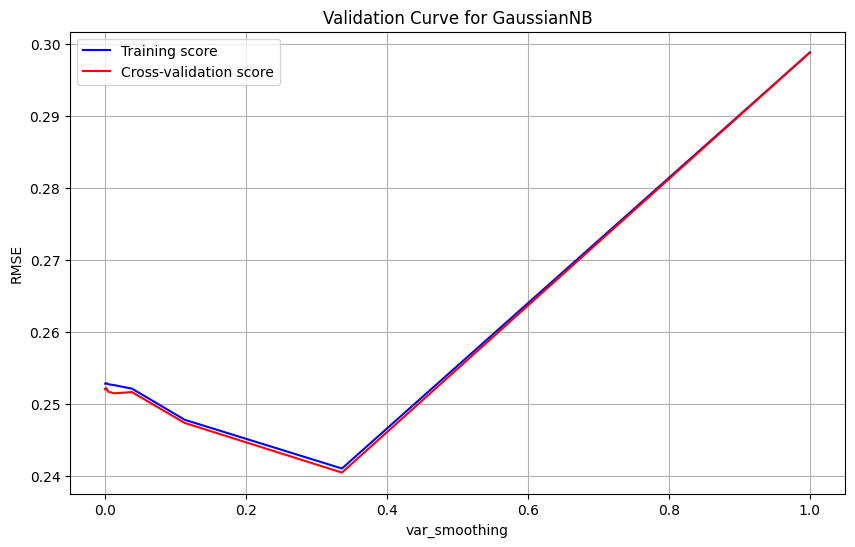

In [ ]:
from sklearn.model_selection import validation_curve
import numpy as np

# Function to plot validation curves
def plot_validation_curve(estimator, title, X, y, param_name, param_range, cv=5, scoring="neg_root_mean_squared_error"):
    train_scores, test_scores = validation_curve(
        estimator=estimator,
        X=X,
        y=y,
        param_name=param_name,
        param_range=param_range,
        cv=cv,
        scoring=scoring
    )

    train_mean = -np.mean(train_scores, axis=1)
    test_mean = -np.mean(test_scores, axis=1)

    plt.figure(figsize=(10, 6))
    plt.plot(param_range, train_mean, label="Training score", color="blue")
    plt.plot(param_range, test_mean, label="Cross-validation score", color="red")

    plt.title(title)
    plt.xlabel(param_name)
    plt.ylabel("RMSE")
    plt.legend(loc="best")
    plt.grid()
    plt.show()
param_range = np.logspace(-9, 0, 20)
plot_validation_curve(model,
                     "Validation Curve for GaussianNB",
                     x_train,
                     y_train,
                     "var_smoothing",
                     param_range)

*As var_smoothing increases, the error goes up — performance drops.

*Training and validation scores stay close throughout, so no signs of overfitting.

*At higher values, the model gets too simple and starts missing patterns — underfitting kicks in.

As Training size increase the rmse increase but training and test rmse ther gap small so somehow there is underfit

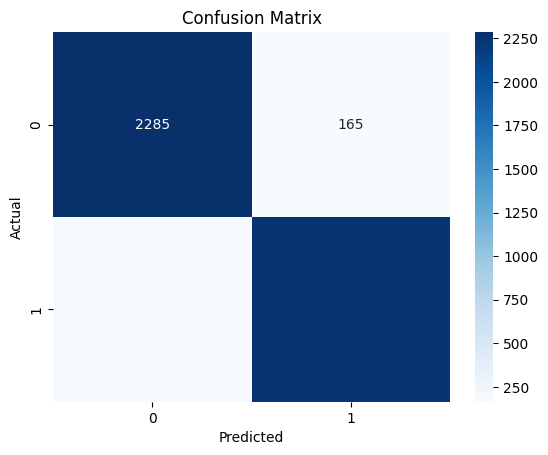

In [ ]:
cm = confusion_matrix(y_test, y_pred)

# Plot confusion matrix
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Confusion Matrix")
plt.show()

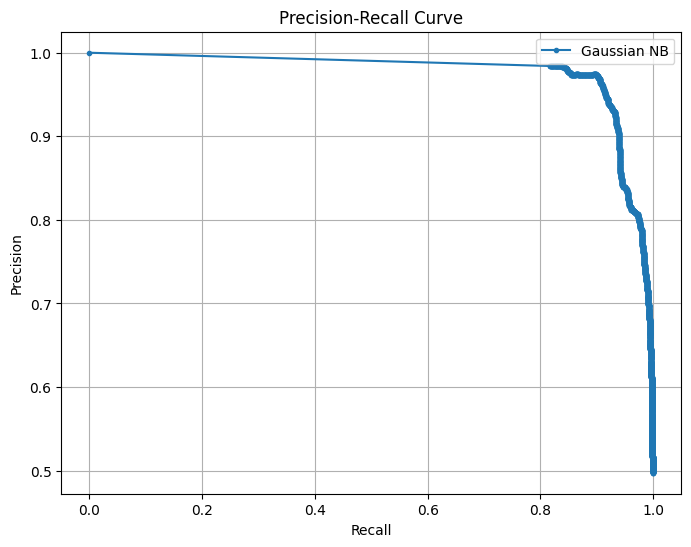

In [ ]:
from sklearn.metrics import confusion_matrix, precision_recall_curve, roc_curve, auc

# Generate predicted probabilities
y_probs_clf = model.predict_proba(x_test)[:, 1]

# Compute precision and recall
precision, recall, thresholds = precision_recall_curve(y_test, y_probs_clf)

# Plot Precision-Recall curve
plt.figure(figsize=(8, 6))
plt.plot(recall, precision, marker=".", label="Gaussian NB")
plt.xlabel("Recall")
plt.ylabel("Precision")
plt.title("Precision-Recall Curve")
plt.legend()
plt.grid()
plt.show()

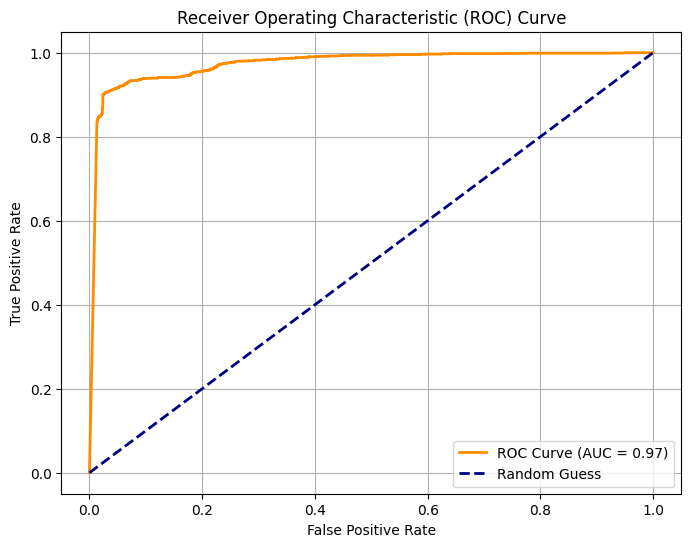

In [ ]:
# Compute ROC curve and AUC
fpr, tpr, thresholds = roc_curve(y_test, y_probs_clf)
roc_auc = auc(fpr, tpr)

# Plot ROC curve
plt.figure(figsize=(8, 6))
plt.plot(fpr, tpr, color="darkorange", lw=2, label=f"ROC Curve (AUC = {roc_auc:.2f})")
plt.plot([0, 1], [0, 1], color="navy", lw=2, linestyle="--", label="Random Guess")
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("Receiver Operating Characteristic (ROC) Curve")
plt.legend(loc="lower right")
plt.grid()
plt.show()

In [ ]:
df

,age,gender,cholesterol,gluc,smoke,alco,active,cardio,bmi,pulse_pressure,hypertension,obesity
0,50.0,2,1,1,0,0,1,0,21.967120,30,0,0
1,55.0,1,3,1,0,0,1,1,34.927679,50,1,1
2,52.0,1,3,1,0,0,0,1,23.507805,60,0,0
3,48.0,2,1,1,0,0,1,1,28.710479,50,1,0
4,48.0,1,1,1,0,0,0,0,23.011177,40,0,0
...,...,...,...,...,...,...,...,...,...,...,...,...
69994,58.0,1,1,1,0,0,1,1,29.384757,70,1,0
69995,53.0,2,1,1,1,0,1,0,26.927438,40,0,0
69997,52.0,2,3,1,0,1,0,1,31.353579,90,1,1
69998,61.0,1,1,2,0,0,0,1,27.099251,55,0,0


when the normalized values of the feature changes that affect the average model prediction may affect by increase or decrease or doesn't affect it

# Permutation Feature Importance

In [ ]:
X_df = pd.DataFrame(X_scaled, columns=x.columns)

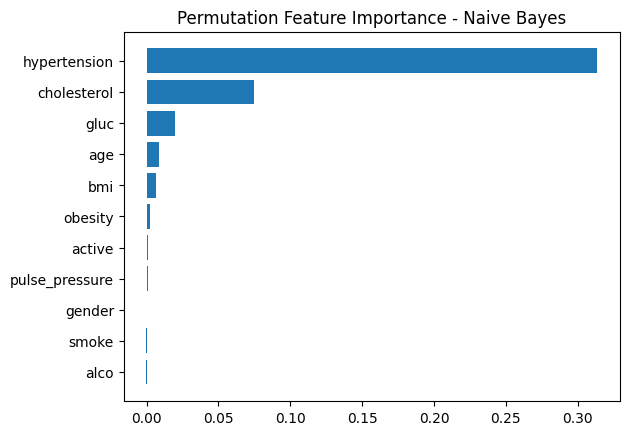

In [ ]:
from sklearn.inspection import permutation_importance

result = permutation_importance(model, x_test, y_test, n_repeats=10, random_state=42)
sorted_idx = result.importances_mean.argsort()

plt.barh(X_df.columns[sorted_idx], result.importances_mean[sorted_idx])
plt.title("Permutation Feature Importance - Naive Bayes")
plt.show()

It says that that when shuffle the columns and see if it affect the model prediction(degrade) if yes then that feature is important so we got bmi is the most important feature

# **LOFO (Leave-One-Feature-Out Importance):**

In [ ]:
x.columns

Index(['age', 'gender', 'cholesterol', 'gluc', 'smoke', 'alco', 'active',
       'bmi', 'pulse_pressure', 'hypertension', 'obesity'],
      dtype='object')

In [ ]:
x_train

array([[-0.48830641, -0.73381905, -0.53874511, ...,  0.07351073,
         1.35597431,  1.68076139],
       [-1.81955766, -0.73381905, -0.53874511, ...,  0.03214404,
        -0.7374771 , -0.59496845],
       [-0.19247279,  1.36273378,  2.40335127, ...,  0.11487742,
         1.35597431, -0.59496845],
       ...,
       [-0.48830641,  1.36273378, -0.53874511, ...,  0.03214404,
        -0.7374771 , -0.59496845],
       [ 0.39919443,  1.36273378, -0.53874511, ...,  0.07351073,
         1.35597431, -0.59496845],
       [ 1.58252887, -0.73381905,  2.40335127, ...,  0.07351073,
        -0.7374771 ,  1.68076139]])

In [ ]:
X_train_df =  pd.DataFrame(x_train, columns=x.columns)

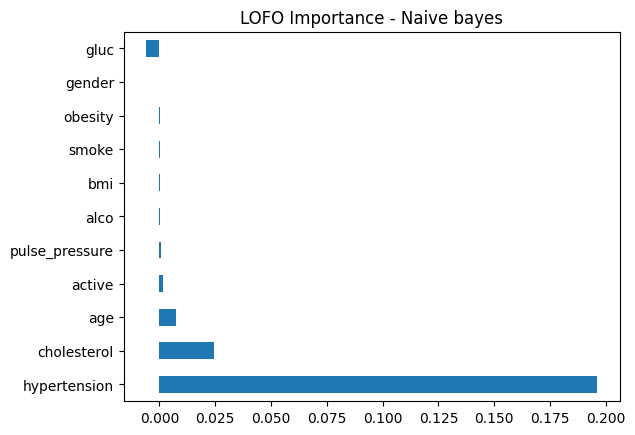

In [ ]:
from sklearn.model_selection import cross_val_score

baseline = cross_val_score(model, x_train, y_train, cv=5).mean()

lofo_scores = {}
for col in X_df.columns:
    X_lofo = X_train_df.drop(columns=[col])
    score = cross_val_score(model, X_lofo, y_train, cv=5).mean()
    lofo_scores[col] = baseline - score

lofo_df = pd.Series(lofo_scores).sort_values(ascending=False)
lofo_df.plot(kind='barh')
plt.title("LOFO Importance - Naive bayes")
plt.show()

# **ALE**

In [ ]:
!pip install alibi

In [ ]:
from alibi.explainers import ALE
from alibi.explainers.ale import plot_ale


In [ ]:
feature = ['age','gender','cholesterol','gluc','smoke','alco','active','bmi','pulse_pressure','hypertension','obesity']

In [ ]:
proba_fun_gnb = model.predict_proba
proba_ale_gnb = ALE(proba_fun_gnb, feature_names=feature, target_names=["class 0", "class 1"])
proba_exp_gnb = proba_ale_gnb.explain(x_train)

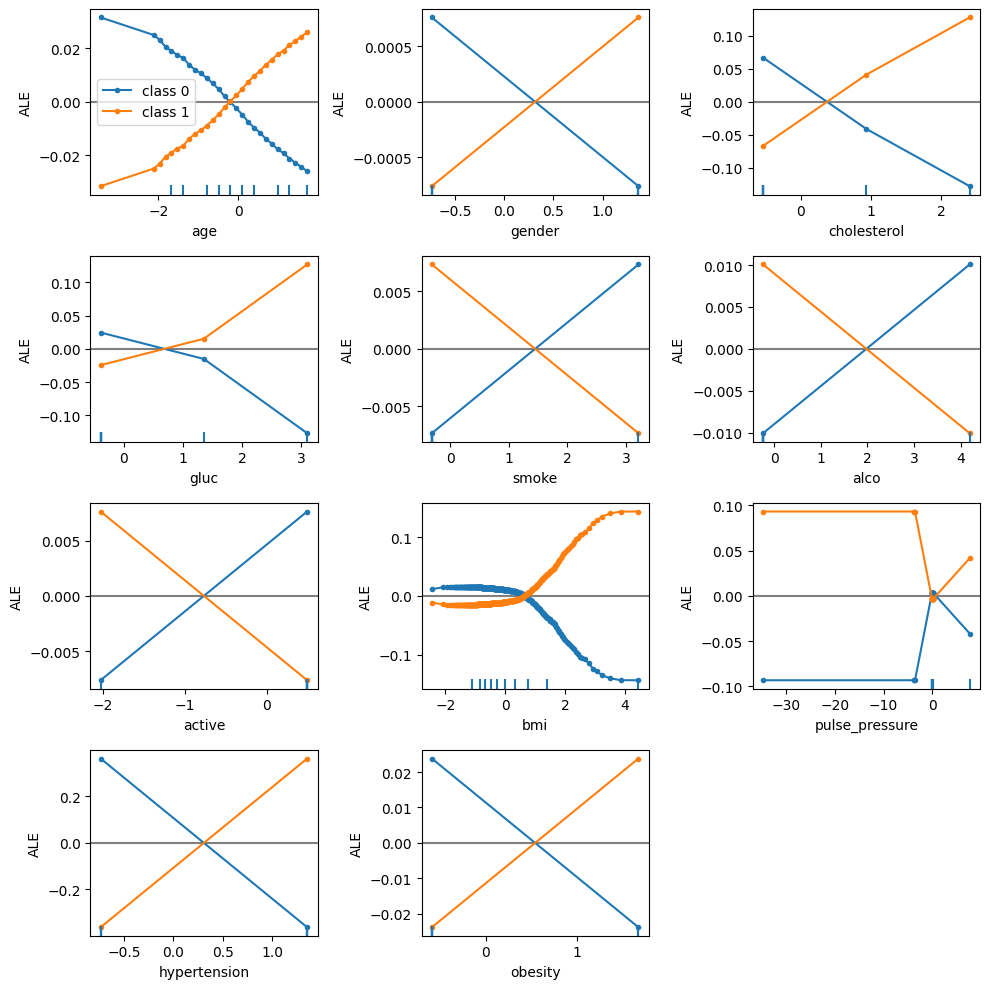

In [ ]:
plot_ale(proba_exp_gnb, n_cols=3, fig_kw={'figwidth': 10, 'figheight': 10}, sharey=None);

This ALE plot illustrates  effect of each feature on the predicted probability of the target class. Features like  hypertension and obesity show stronger influence, indicating they significantly impact the model's risk prediction.

# **PDP**

In [ ]:
from sklearn.inspection import PartialDependenceDisplay

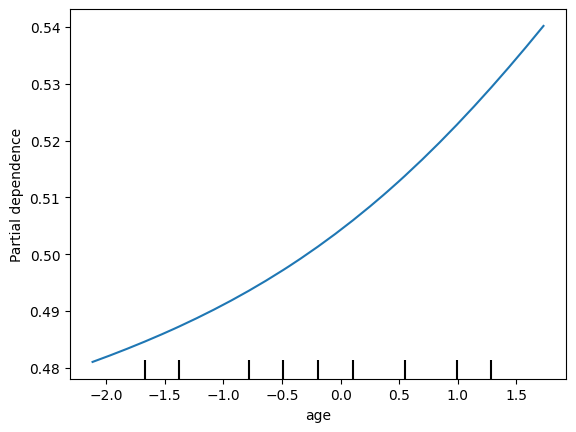

In [ ]:
features = [0]
PartialDependenceDisplay.from_estimator(model, x_test, features,feature_names=feature)

# **ICE**

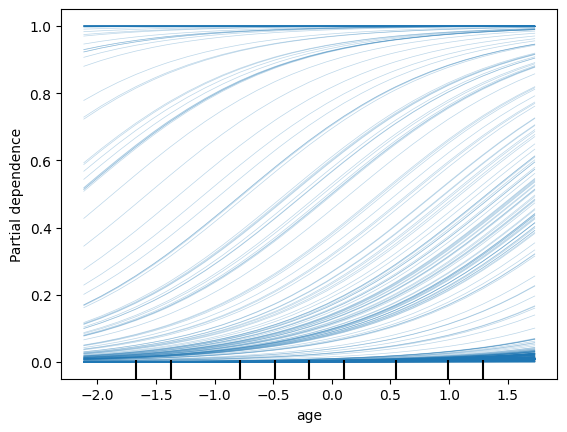

In [ ]:
features = [0]
PartialDependenceDisplay.from_estimator(model, x_test, features,feature_names=feature, kind='individual')

# **FriedmanHStatistic**

In [ ]:
# Install required libraries
!pip install artemis
!pip install pyartemis


In [ ]:
import random
from artemis.interactions_methods.model_agnostic import FriedmanHStatisticMethod


In [ ]:
random.seed(8)
X_exp = random.choices(X_scaled, k=100)
X_exp = pd.DataFrame(X_exp, columns=X_df.columns)

h_stat = FriedmanHStatisticMethod()
h_stat.fit(model, X_exp)


/usr/local/lib/python3.11/dist-packages/sklearn/utils/validation.py:2732: UserWarning: X has feature names, but GaussianNB was fitted without feature names
  warnings.warn(
/usr/local/lib/python3.11/dist-packages/sklearn/utils/validation.py:2732: UserWarning: X has feature names, but GaussianNB was fitted without feature names
  warnings.warn(
/usr/local/lib/python3.11/dist-packages/sklearn/utils/validation.py:2732: UserWarning: X has feature names, but GaussianNB was fitted without feature names
  warnings.warn(
/usr/local/lib/python3.11/dist-packages/sklearn/utils/validation.py:2732: UserWarning: X has feature names, but GaussianNB was fitted without feature names
  warnings.warn(
/usr/local/lib/python3.11/dist-packages/sklearn/utils/validation.py:2732: UserWarning: X has feature names, but GaussianNB was fitted without feature names
  warnings.warn(
/usr/local/lib/python3.11/dist-packages/sklearn/utils/validation.py:2732: UserWarning: X has feature names, but GaussianNB was fitted w

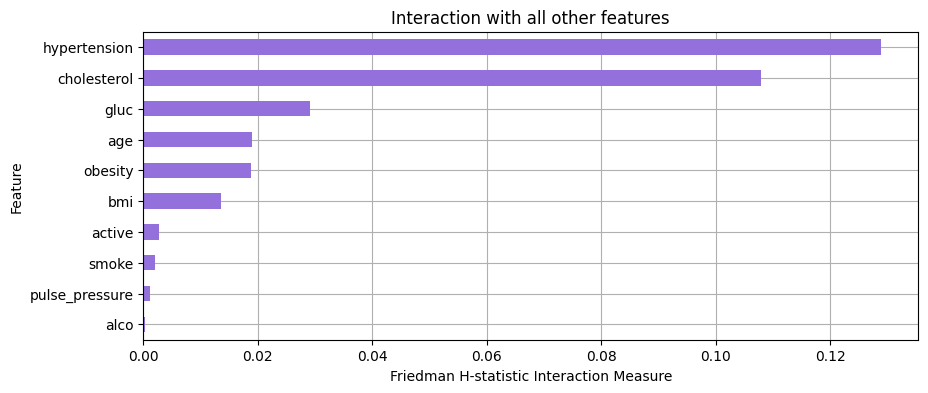

In [ ]:
fig, ax = plt.subplots(figsize=(10, 4))
h_stat.plot('bar_chart_ova', ax=ax)
plt.show()

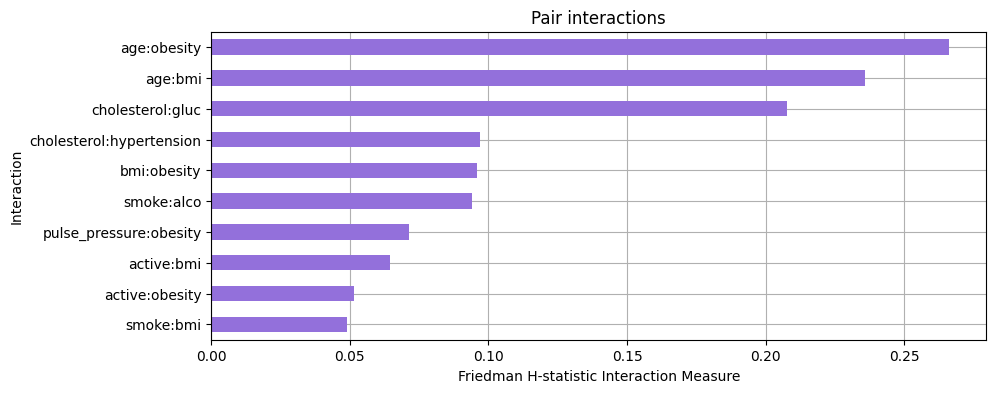

In [ ]:
# Pairwise interactions
fig, ax = plt.subplots(figsize=(10, 4))
h_stat.plot(vis_type='bar_chart',ax=ax)

In [ ]:
!pip install lime

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 275.7/275.7 kB 5.9 MB/s eta 0:00:00
  Preparing metadata (setup.py) ... done
  Created wheel for lime: filename=lime-0.2.0.1-py3-none-any.whl size=283834 sha256=0616ee4e95c8db40766e4f1457b7f25ec7759dc1e385446d51d50365798594cb
  Stored in directory: /root/.cache/pip/wheels/85/fa/a3/9c2d44c9f3cd77cf4e533b58900b2bf4487f2a17e8ec212a3d
Successfully built lime


# **LIME**

In [ ]:
import lime
from lime.lime_tabular import LimeTabularExplainer


In [ ]:
x_train = np.array(x_train)
x_test = np.array(x_test)

In [ ]:
explainer = LimeTabularExplainer(training_data=x_train,feature_names=feature,class_names=['no_disease', 'disease'],mode='classification')

In [ ]:
def predict_fn(x):
    preds = model.predict(x)
    if preds.ndim == 1 or preds.shape[1] == 1:
        preds = preds.flatten()
        return np.stack([1 - preds, preds], axis=1)
    return preds

In [ ]:
i = 1
explanation = explainer.explain_instance(
    data_row=x_test[i],
    predict_fn=predict_fn,
    num_features=10
)

explanation.show_in_notebook()


In [ ]:
# choose another feature
i = 2
explanation = explainer.explain_instance(
    data_row=x_test[i],
    predict_fn=predict_fn,
    num_features=10
)

explanation.show_in_notebook()